In [11]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

df = pd.read_csv("incident records.csv")


In [12]:
df["date"] = pd.to_datetime(
    df["iyear"].astype(str) + "-" + df["imonth"].astype(str) + "-01"
)

monthly = df.groupby("date").size().reset_index(name="incidents")

prophet_df = monthly.rename(columns={"date": "ds", "incidents": "y"})

prophet_df = prophet_df.dropna(subset=["ds"])

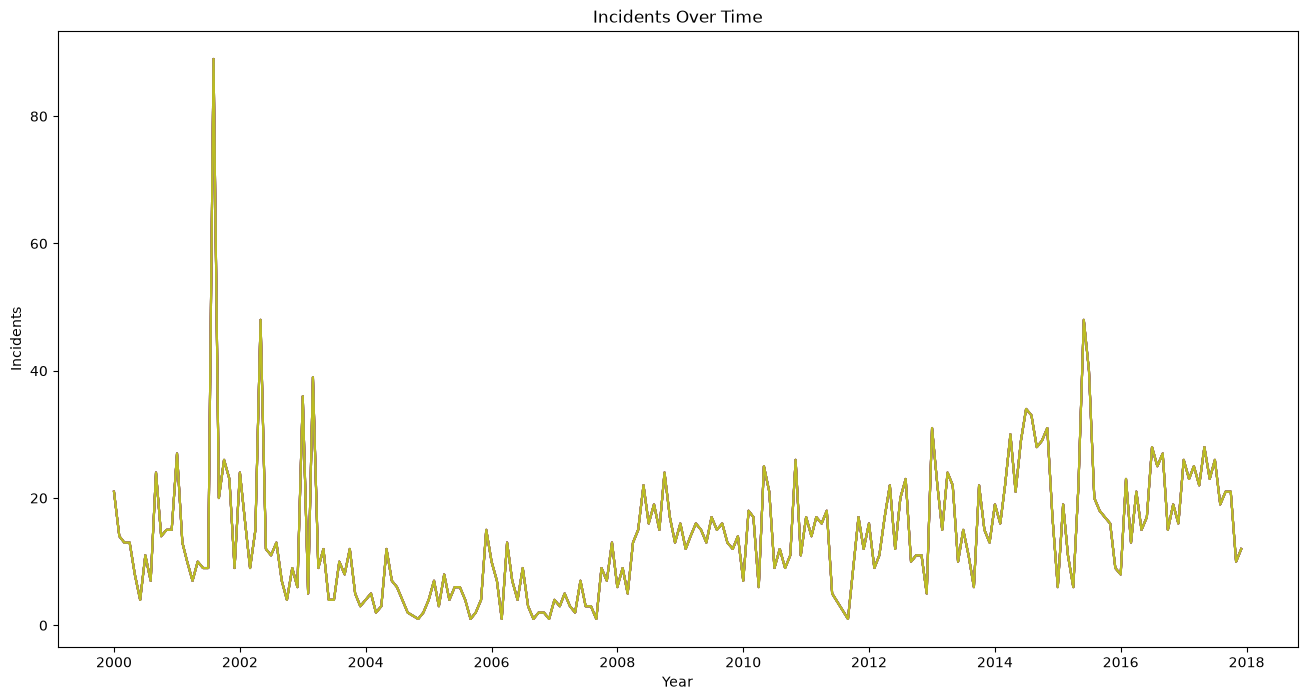

In [13]:
incidents = df.groupby('date').count()

fig, ax = plt.subplots(figsize= (16, 8))

ax.plot(incidents.index, incidents.values)

plt.xlabel('Year')
plt.ylabel('Incidents')
plt.title('Incidents Over Time')

plt.show()

In [14]:
model = Prophet()

In [15]:
model.fit(prophet_df)

16:32:05 - cmdstanpy - INFO - Chain [1] start processing


16:32:05 - cmdstanpy - INFO - Chain [1] done processing


In [16]:
future = model.make_future_dataframe(periods=24, freq="MS")

forecast = model.predict(future)


Text(91.72222222222221, 0.5, 'Number of Incidents')

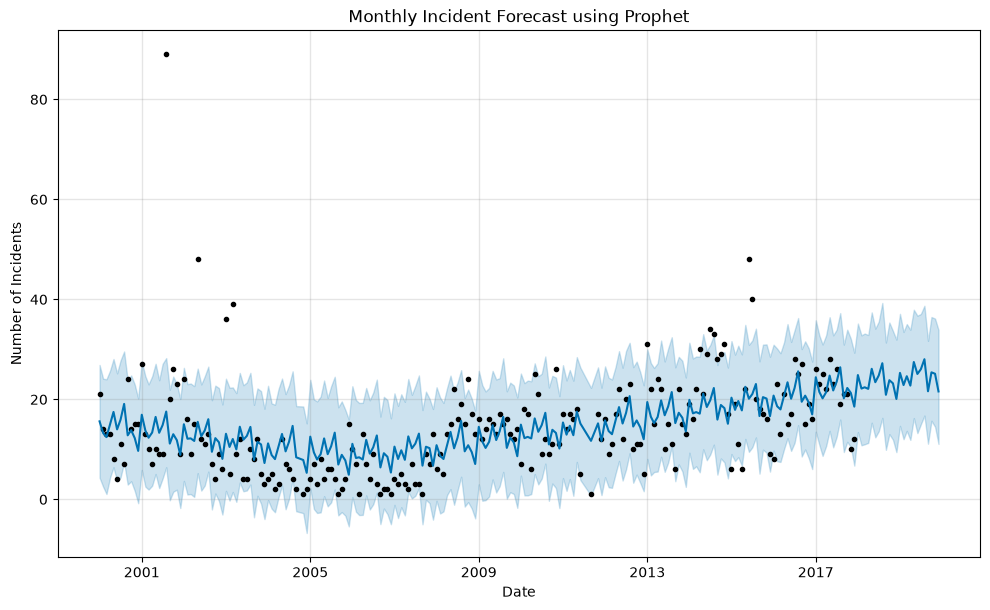

In [17]:
fig = model.plot(forecast)
plt.title("Monthly Incident Forecast using Prophet")
plt.xlabel("Date")
plt.ylabel("Number of Incidents")

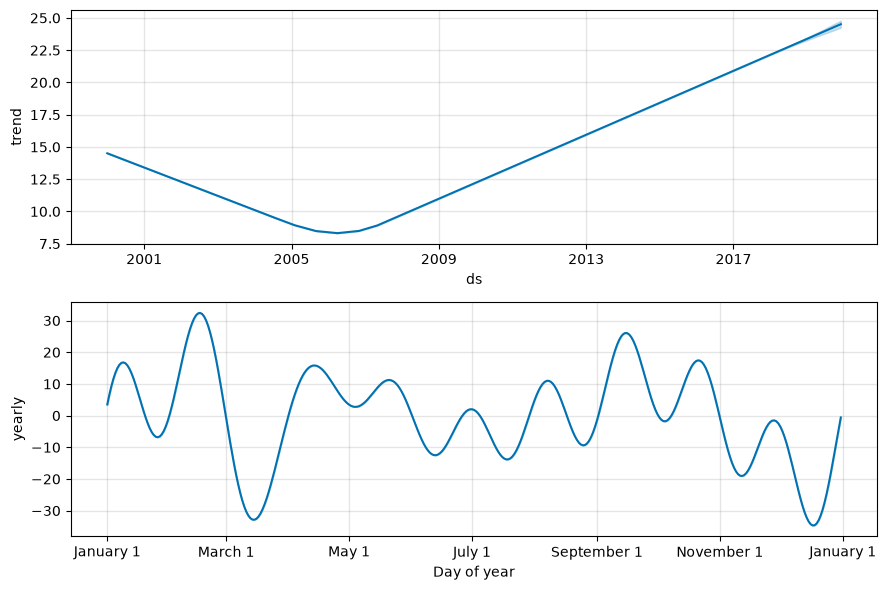

In [18]:
fig2 = model.plot_components(forecast)
plt.show()